In [2]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import glob
from pathlib import Path

import numpy as np
import pandas as pd

from aicsimageio import AICSImage, readers

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['svg.fonttype'] = 'none'

## load layout files for multiple experiments

In [4]:
Experiment1_Layout = pd.read_csv("250905_mACPOLR2A_Kinetic_pSer2/METADATA/250905_mACPOLR2A_Kinetic_pSer2.csv")
Experiment2_Layout = pd.read_csv("250912_mACPOLR2A_Kinetic_pSer2/METADATA/250912_mACPOLR2A_Kinetic_pSer2.csv")
Experiment3_Layout = pd.read_csv("260522_mACPOLR2A_Kinetic_pSer2/METADATA/260522_mACPOLR2A_Kinetic_pSer2.csv")

## load quantification files and assemble into dataframes

In [6]:
Experiment1_Quantification_Directory = Path("/Users/alexandergillis/Desktop/KATANA_PULL/250905_mACPOLR2A_Kinetic_pSer2/20250909_163903_624/QUANTIFICATION")
Experiment2_Quantification_Directory = Path("/Users/alexandergillis/Desktop/KATANA_PULL/250912_mACPOLR2A_Kinetic_pSer2/20250917_181651_148/QUANTIFICATION/")
Experiment3_Quantification_Directory = Path("/Users/alexandergillis/Desktop/KATANA_PULL/260522_mACPOLR2A_Kinetic_pSer2/20260526_181658_086/QUANTIFICATION")

Experiment1_Quantification_Files = glob.glob(str(Experiment1_Quantification_Directory / "*.csv"))
Experiment2_Quantification_Files = glob.glob(str(Experiment2_Quantification_Directory / "*.csv"))
Experiment3_Quantification_Files = glob.glob(str(Experiment3_Quantification_Directory / "*.csv"))

[len(f) for f in [Experiment1_Quantification_Files, Experiment2_Quantification_Files, Experiment3_Quantification_Files]]

[916, 960, 960]

In [7]:
qdfs = list()


for f in tqdm(Experiment1_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment1_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment1_PerCell['file'].tolist()


wellnames = [f[11:14] for f in files]
Experiment1_PerCell['well'] = wellnames

fovs = [f[40:44] for f in files]
Experiment1_PerCell['fov'] = fovs

100%|█████████████████████████████████████████| 916/916 [00:15<00:00, 61.06it/s]


In [8]:
Intensities_Experiment1 = pd.DataFrame({
    "WELL" : Experiment1_PerCell['well'],
    "IF_561_Intensity" : Experiment1_PerCell['Channel:0:0_intensity_mean_561'],
    "GFP_488_Intensity" : Experiment1_PerCell['Channel:0:0_intensity_mean_488'],
    "DAPI_Intensity" : Experiment1_PerCell['Channel:0:0_intensity_mean_405'],
    "NucleusArea" : Experiment1_PerCell['Channel:0:0_area']
})

In [9]:
qdfs = list()


for f in tqdm(Experiment2_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment2_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment2_PerCell['file'].tolist()

wellnames = [f[4:7] for f in files]
Experiment2_PerCell['well'] = wellnames

fovs = [f[40:44] for f in files]
Experiment2_PerCell['fov'] = fovs

100%|█████████████████████████████████████████| 960/960 [00:15<00:00, 62.14it/s]


In [10]:
Intensities_Experiment2 = pd.DataFrame({
    "WELL" : Experiment2_PerCell['well'],
    "IF_561_Intensity" : Experiment2_PerCell['Nuclei_intensity_mean_561'],
    "GFP_488_Intensity" : Experiment2_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment2_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment2_PerCell['Nuclei_area']
})

In [11]:
qdfs = list()


for f in tqdm(Experiment3_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment3_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment3_PerCell['file'].tolist()

wellnames = [f[11:14] for f in files]
Experiment3_PerCell['well'] = wellnames

fovs = [f[46:50] for f in files]
Experiment3_PerCell['fov'] = fovs

100%|████████████████████████████████████████| 960/960 [00:05<00:00, 179.82it/s]


In [13]:
Experiment3_PerCell

,label,Channel:0:0_centroid_0,Channel:0:0_centroid_1,Channel:0:0_area,Channel:0:0_area_convex,Channel:0:0_axis_major_length,Channel:0:0_axis_minor_length,Channel:0:0_eccentricity,Channel:0:0_extent,Channel:0:0_feret_diameter_max,...,Channel:0:0_intensity_mean_405,Channel:0:0_intensity_max_405,Channel:0:0_intensity_min_405,Channel:0:0_intensity_sd_405,Channel:0:0_intensity_median_405,Channel:0:0_intensity_sum_405,TimepointID,file,well,fov
0,1,15.268796,38.803726,1503.0,1537.0,54.417622,36.974824,0.733709,0.781185,56.435804,...,358.697937,519.0,198.0,53.792206,360.0,539123.0,1,"nuclei_WellH06_Channel647,488,561,405_Seq0116_...",H06,0002
1,2,23.438198,208.516348,2508.0,2562.0,60.464775,53.270545,0.473083,0.806172,61.522354,...,367.440590,634.0,182.0,60.957989,362.0,921541.0,1,"nuclei_WellH06_Channel647,488,561,405_Seq0116_...",H06,0002
2,3,10.908313,287.949878,818.0,961.0,44.870463,28.547260,0.771512,0.621581,49.244289,...,351.102689,501.0,208.0,48.275029,350.0,287202.0,1,"nuclei_WellH06_Channel647,488,561,405_Seq0116_...",H06,0002
3,4,9.269455,356.623541,1028.0,1064.0,57.036633,24.872285,0.899910,0.725989,59.413803,...,449.055447,732.0,199.0,71.845691,451.0,461629.0,1,"nuclei_WellH06_Channel647,488,561,405_Seq0116_...",H06,0002
4,5,16.861869,471.150538,2418.0,2505.0,77.119275,42.418910,0.835136,0.746296,83.432608,...,474.361456,1576.0,200.0,106.723714,467.0,1147006.0,1,"nuclei_WellH06_Channel647,488,561,405_Seq0116_...",H06,0002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563859,553,2285.199057,2085.539623,1060.0,1088.0,43.149795,31.553762,0.682098,0.820433,45.803930,...,384.657547,708.0,186.0,96.381977,375.5,407737.0,1,"nuclei_WellL04_Channel647,488,561,405_Seq0198_...",L04,0004
563860,554,2289.025424,1965.417565,1298.0,1367.0,53.979974,31.973943,0.805696,0.837419,53.488316,...,459.141757,867.0,191.0,127.677994,461.0,595966.0,1,"nuclei_WellL04_Channel647,488,561,405_Seq0198_...",L04,0004
563861,555,2292.582659,1056.039306,865.0,920.0,46.558280,25.402255,0.838045,0.702110,47.010637,...,467.603468,802.0,232.0,92.908675,466.0,404477.0,1,"nuclei_WellL04_Channel647,488,561,405_Seq0198_...",L04,0004
563862,556,2294.195254,2193.293420,927.0,951.0,54.219292,22.954257,0.905962,0.795026,53.758720,...,282.491909,410.0,197.0,36.086342,281.0,261870.0,1,"nuclei_WellL04_Channel647,488,561,405_Seq0198_...",L04,0004


In [15]:
Intensities_Experiment3 = pd.DataFrame({
    "WELL" : Experiment3_PerCell['well'],
    "IF_647_Intensity" : Experiment3_PerCell['Channel:0:0_intensity_mean_647'],
    "IF_561_Intensity" : Experiment3_PerCell['Channel:0:0_intensity_mean_561'],
    "GFP_488_Intensity" : Experiment3_PerCell['Channel:0:0_intensity_mean_488'],
    "DAPI_Intensity" : Experiment3_PerCell['Channel:0:0_intensity_mean_405'],
    "NucleusArea" : Experiment3_PerCell['Channel:0:0_area']
})

## average by individual wells, add cell counts, and merge with layouts

In [16]:
CountsByWell1 = Intensities_Experiment1.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell1.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment1 = Intensities_Experiment1.groupby('WELL').mean().reset_index().merge(Experiment1_Layout, how = 'left')
IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.merge(CountsByWell1, how = 'left')
IntensitiesByWell_Experiment1['EXPERIMENT'] = '250905_mACPOLR2A_Kinetic_pSer2'

CountsByWell2 = Intensities_Experiment2.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell2.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment2 = Intensities_Experiment2.groupby('WELL').mean().reset_index().merge(Experiment2_Layout, how = 'left')
IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.merge(CountsByWell2, how = 'left')
IntensitiesByWell_Experiment2['EXPERIMENT'] = '250912_mACPOLR2A_Kinetic_pSer2'

CountsByWell3 = Intensities_Experiment3.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell3.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment3 = Intensities_Experiment3.groupby('WELL').mean().reset_index().merge(Experiment3_Layout, how = 'left')
IntensitiesByWell_Experiment3 = IntensitiesByWell_Experiment3.merge(CountsByWell3, how = 'left')
IntensitiesByWell_Experiment3['EXPERIMENT'] = '260522_mACPOLR2A_Kinetic_pSer2'

In [17]:
IntensitiesByWell_Experiment1['ROW'] = [x[:1] for x in IntensitiesByWell_Experiment1['WELL']]
IntensitiesByWell_Experiment1['COLUMN'] = [x[1:] for x in IntensitiesByWell_Experiment1['WELL']]

IntensitiesByWell_Experiment2['ROW'] = [x[:1] for x in IntensitiesByWell_Experiment2['WELL']]
IntensitiesByWell_Experiment2['COLUMN'] = [x[1:] for x in IntensitiesByWell_Experiment2['WELL']]

IntensitiesByWell_Experiment3['ROW'] = [x[:1] for x in IntensitiesByWell_Experiment3['WELL']]
IntensitiesByWell_Experiment3['COLUMN'] = [x[1:] for x in IntensitiesByWell_Experiment3['WELL']]

## save well mean summaries of each experiment

In [20]:
IntensitiesByWell_Experiment3.head()

,WELL,IF_647_Intensity,IF_561_Intensity,GFP_488_Intensity,DAPI_Intensity,NucleusArea,CELL,DRUG,DRUG_CONCENTRATION,TIME_MINUTES,PRIMARY,SECONDARY,TotalNumberCells,EXPERIMENT,ROW,COLUMN
0,C03,2443.855821,1070.411472,224.795369,416.762780,1793.712871,HCT116 OsTIRF74G,Vehicle,0,480,pSer2 Pol II (3E10),Goat anti-rat Alexa568,3030,260522_mACPOLR2A_Kinetic_pSer2,C,03
1,C04,2484.863721,1156.245999,244.472794,457.375945,1736.815759,HCT116 OsTIRF74G,Vehicle,0,480,pSer2 Pol II (3E10),Goat anti-rat Alexa568,2627,260522_mACPOLR2A_Kinetic_pSer2,C,04
2,C05,2482.685799,1155.970583,244.984875,459.780731,1748.355051,HCT116 OsTIRF74G,Vehicle,0,480,pSer2 Pol II (3E10),Goat anti-rat Alexa568,2732,260522_mACPOLR2A_Kinetic_pSer2,C,05
3,C06,2442.975076,1095.950166,245.775548,438.659220,1712.297945,HCT116 OsTIRF74G,Vehicle,0,480,pSer2 Pol II (3E10),Goat anti-rat Alexa568,2920,260522_mACPOLR2A_Kinetic_pSer2,C,06
4,C07,2449.590743,1141.219066,247.274791,449.476018,1789.335280,HCT116 OsTIRF74G,Vehicle,0,480,pSer2 Pol II (3E10),Goat anti-rat Alexa568,2568,260522_mACPOLR2A_Kinetic_pSer2,C,07


In [21]:
IntensitiesByWell_Experiment1.to_csv('250905_mACPOLR2A_Kinetic_pSer2/250905_mACPOLR2A_Kinetic_pSer2_well_means.csv')
IntensitiesByWell_Experiment2.to_csv('250912_mACPOLR2A_Kinetic_pSer2/250912_mACPOLR2A_Kinetic_pSer2_well_means.csv')
IntensitiesByWell_Experiment3.to_csv('260522_mACPOLR2A_Kinetic_pSer2/260522_mACPOLR2A_Kinetic_pSer2_well_means.csv')

## heat maps of individual experiments

<Axes: xlabel='COLUMN', ylabel='ROW'>

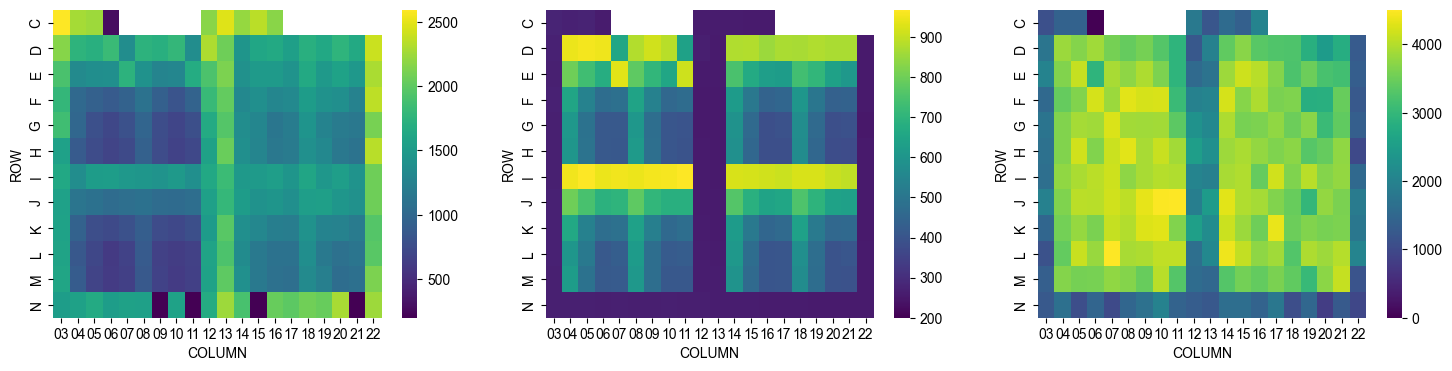

In [22]:
f, a = plt.subplots(ncols = 3, figsize = (18,4))

heat = IntensitiesByWell_Experiment1.pivot(index = 'ROW', columns = 'COLUMN', values = 'IF_561_Intensity')
sns.heatmap(heat, cmap = 'viridis', ax = a[0], vmin = 200)

heat = IntensitiesByWell_Experiment1.pivot(index = 'ROW', columns = 'COLUMN', values = 'GFP_488_Intensity')
sns.heatmap(heat, cmap = 'viridis', ax = a[1], vmin = 200)

heat = IntensitiesByWell_Experiment1.pivot(index = 'ROW', columns = 'COLUMN', values = 'TotalNumberCells')
sns.heatmap(heat, cmap = 'viridis', ax = a[2], vmin = 0)

<Axes: xlabel='COLUMN', ylabel='ROW'>

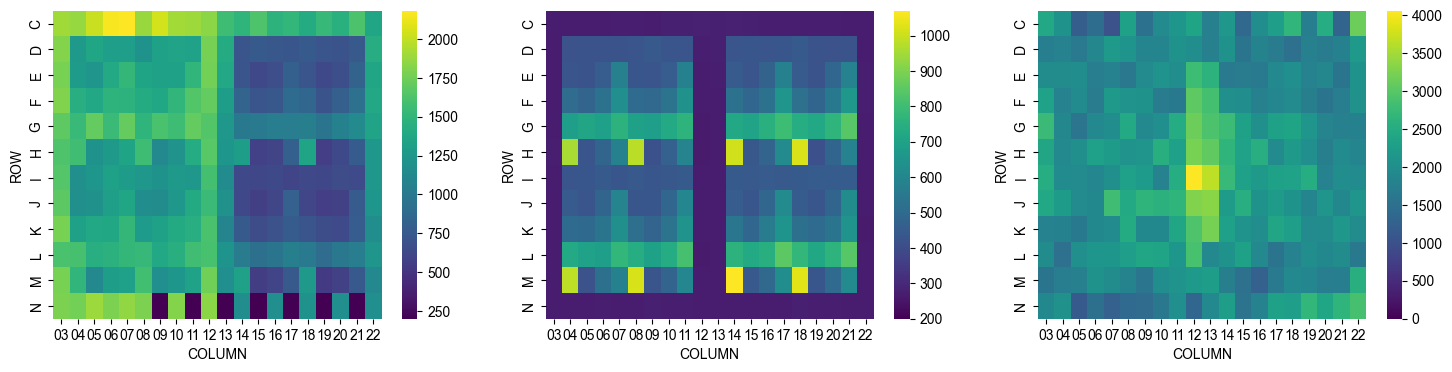

In [23]:
f, a = plt.subplots(ncols = 3, figsize = (18,4))

heat = IntensitiesByWell_Experiment2.pivot(index = 'ROW', columns = 'COLUMN', values = 'IF_561_Intensity')
sns.heatmap(heat, cmap = 'viridis', ax = a[0], vmin = 200)

heat = IntensitiesByWell_Experiment2.pivot(index = 'ROW', columns = 'COLUMN', values = 'GFP_488_Intensity')
sns.heatmap(heat, cmap = 'viridis', ax = a[1], vmin = 200)

heat = IntensitiesByWell_Experiment2.pivot(index = 'ROW', columns = 'COLUMN', values = 'TotalNumberCells')
sns.heatmap(heat, cmap = 'viridis', ax = a[2], vmin = 0)

<Axes: xlabel='COLUMN', ylabel='ROW'>

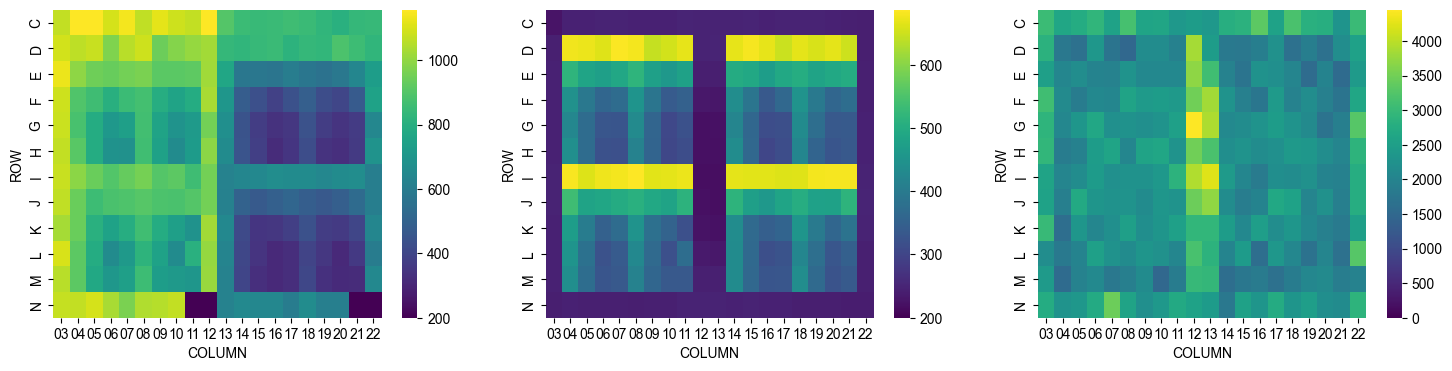

In [24]:
f, a = plt.subplots(ncols = 3, figsize = (18,4))

heat = IntensitiesByWell_Experiment3.pivot(index = 'ROW', columns = 'COLUMN', values = 'IF_561_Intensity')
sns.heatmap(heat, cmap = 'viridis', ax = a[0], vmin = 200)

heat = IntensitiesByWell_Experiment3.pivot(index = 'ROW', columns = 'COLUMN', values = 'GFP_488_Intensity')
sns.heatmap(heat, cmap = 'viridis', ax = a[1], vmin = 200)

heat = IntensitiesByWell_Experiment3.pivot(index = 'ROW', columns = 'COLUMN', values = 'TotalNumberCells')
sns.heatmap(heat, cmap = 'viridis', ax = a[2], vmin = 0)

## examine raw data within each experiment

(0.0, 1000.0)

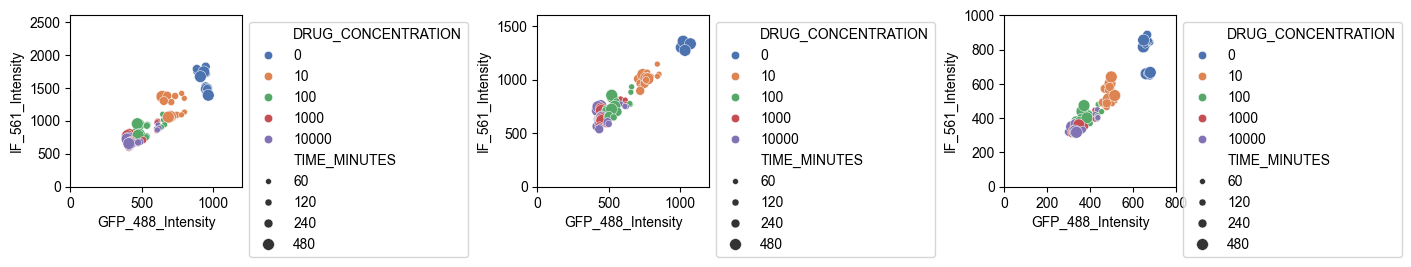

In [25]:
f, a = plt.subplots(ncols = 3, figsize = (14,3), layout = 'constrained')

h = sns.scatterplot(IntensitiesByWell_Experiment1.query('PRIMARY == "Total Pol II (F12)" & CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
                x = "GFP_488_Intensity",
                y = "IF_561_Intensity",
                hue = "DRUG_CONCENTRATION", palette = 'deep',size = 'TIME_MINUTES',
                    ax = a[0])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

h = sns.scatterplot(IntensitiesByWell_Experiment2.query('PRIMARY == "Total Pol II (F12)" & CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
                x = "GFP_488_Intensity",
                y = "IF_561_Intensity",
                hue = "DRUG_CONCENTRATION", palette = 'deep',size = 'TIME_MINUTES',
                    ax = a[1])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

h = sns.scatterplot(IntensitiesByWell_Experiment3.query('PRIMARY == "Total Pol II (F12)" & CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
                x = "GFP_488_Intensity",
                y = "IF_561_Intensity",
                hue = "DRUG_CONCENTRATION", palette = 'deep',size = 'TIME_MINUTES',
                    ax = a[2])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

a[0].set_box_aspect(1)
a[1].set_box_aspect(1)
a[2].set_box_aspect(1)

a[0].set_xlim(0,1200)
a[1].set_xlim(0,1200)
a[2].set_xlim(0,800)

a[0].set_ylim(0,2600)
a[1].set_ylim(0,1600)
a[2].set_ylim(0,1000)

(0.0, 1200.0)

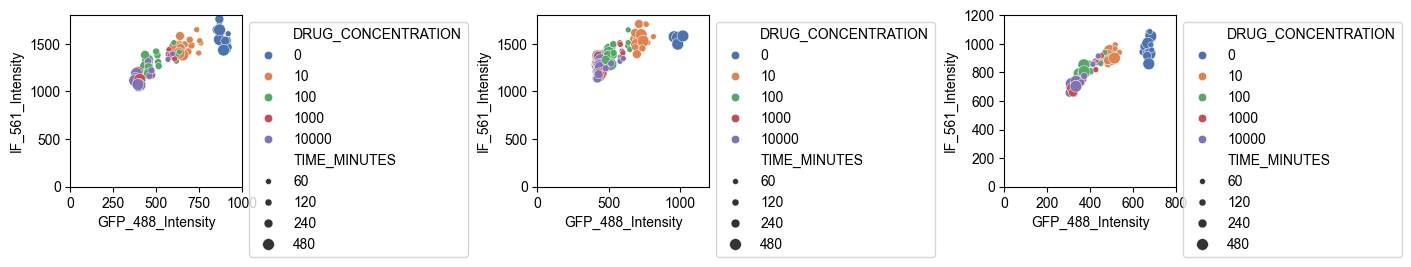

In [26]:
f, a = plt.subplots(ncols = 3, figsize = (14,3), layout = 'constrained')

h = sns.scatterplot(IntensitiesByWell_Experiment1.query('PRIMARY == "pSer2 Pol II (3E10)" & CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
                x = "GFP_488_Intensity",
                y = "IF_561_Intensity",
                hue = "DRUG_CONCENTRATION", palette = 'deep',size = 'TIME_MINUTES',
                    ax = a[0])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

h = sns.scatterplot(IntensitiesByWell_Experiment2.query('PRIMARY == "pSer2 Pol II (3E10)" & CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
                x = "GFP_488_Intensity",
                y = "IF_561_Intensity",
                hue = "DRUG_CONCENTRATION", palette = 'deep',size = 'TIME_MINUTES',
                    ax = a[1])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

h = sns.scatterplot(IntensitiesByWell_Experiment3.query('PRIMARY == "pSer2 Pol II (3E10)" & CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
                x = "GFP_488_Intensity",
                y = "IF_561_Intensity",
                hue = "DRUG_CONCENTRATION", palette = 'deep',size = 'TIME_MINUTES',
                    ax = a[2])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

a[0].set_box_aspect(1)
a[1].set_box_aspect(1)
a[2].set_box_aspect(1)

a[0].set_xlim(0,1000)
a[1].set_xlim(0,1200)
a[2].set_xlim(0,800)

a[0].set_ylim(0,1800)
a[1].set_ylim(0,1800)
a[2].set_ylim(0,1200)

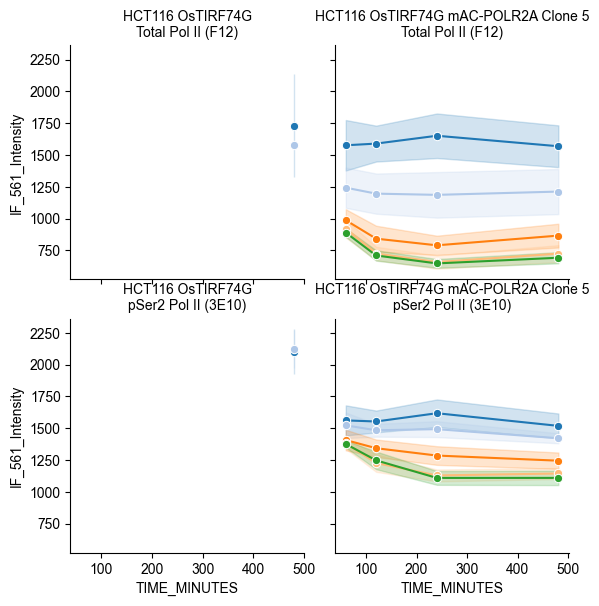

In [27]:
g = sns.FacetGrid(IntensitiesByWell_Experiment1,
                  col = 'CELL',
                  row = 'PRIMARY', row_order = ["Total Pol II (F12)", "pSer2 Pol II (3E10)"]) #margin_titles = True)

g.map_dataframe(sns.lineplot,
                x = 'TIME_MINUTES',
                y = 'IF_561_Intensity',
                hue = 'DRUG_CONCENTRATION', palette = 'tab20',
                marker = 'o',
                errorbar = 'sd')

g.set_titles(template="{col_name}\n{row_name}")

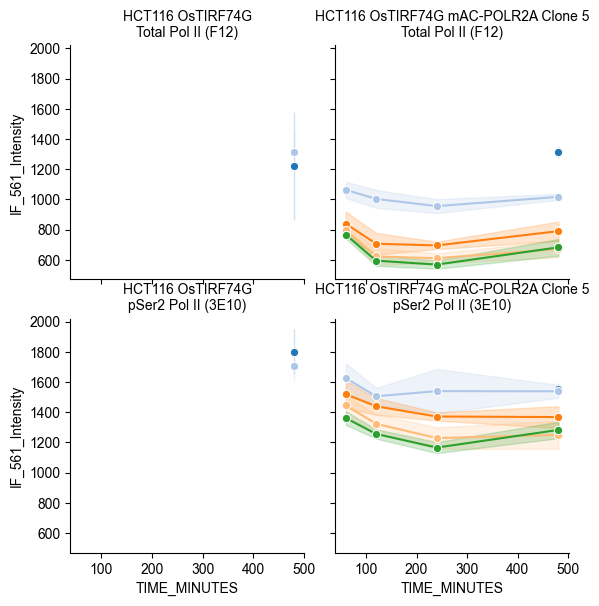

In [28]:
g = sns.FacetGrid(IntensitiesByWell_Experiment2,
                  col = 'CELL',
                  row = 'PRIMARY', row_order = ["Total Pol II (F12)", "pSer2 Pol II (3E10)"]) #margin_titles = True)

g.map_dataframe(sns.lineplot,
                x = 'TIME_MINUTES',
                y = 'IF_561_Intensity',
                hue = 'DRUG_CONCENTRATION', palette = 'tab20',
                marker = 'o',
                errorbar = 'sd')

g.set_titles(template="{col_name}\n{row_name}")

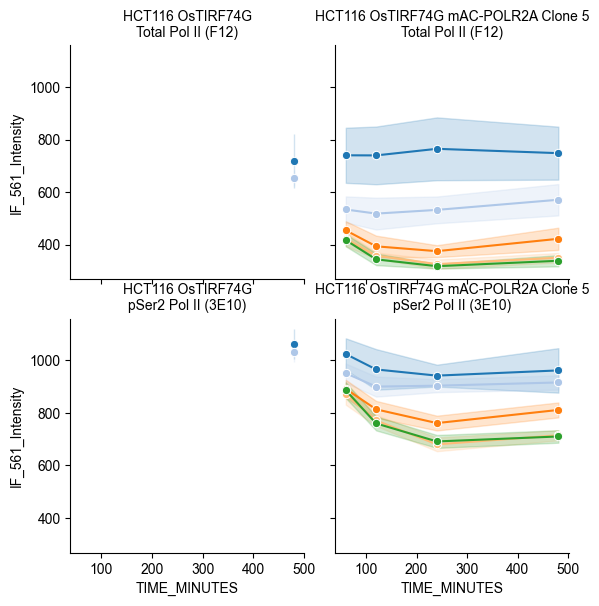

In [29]:
g = sns.FacetGrid(IntensitiesByWell_Experiment3,
                  col = 'CELL',
                  row = 'PRIMARY', row_order = ["Total Pol II (F12)", "pSer2 Pol II (3E10)"]) #margin_titles = True)

g.map_dataframe(sns.lineplot,
                x = 'TIME_MINUTES',
                y = 'IF_561_Intensity',
                hue = 'DRUG_CONCENTRATION', palette = 'tab20',
                marker = 'o',
                errorbar = 'sd')

g.set_titles(template="{col_name}\n{row_name}")

## background subtract and normalise within experiments

In [30]:
E1_GFP_Zero = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G"').GFP_488_Intensity.mean()
E2_GFP_Zero = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G"').GFP_488_Intensity.mean()
E3_GFP_Zero = IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G"').GFP_488_Intensity.mean()

IntensitiesByWell_Experiment1['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment1['GFP_488_Intensity'] - E1_GFP_Zero
IntensitiesByWell_Experiment2['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment2['GFP_488_Intensity'] - E2_GFP_Zero
IntensitiesByWell_Experiment3['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment3['GFP_488_Intensity'] - E3_GFP_Zero

E1_GFP_NV = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG == "Vehicle"').GFP_Intensity_BGS.mean()
E2_GFP_NV = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG == "Vehicle"').GFP_Intensity_BGS.mean()
E3_GFP_NV = IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG == "Vehicle"').GFP_Intensity_BGS.mean()

IntensitiesByWell_Experiment1['GFP_Intensity_FC'] = IntensitiesByWell_Experiment1['GFP_Intensity_BGS'] / E1_GFP_NV
IntensitiesByWell_Experiment2['GFP_Intensity_FC'] = IntensitiesByWell_Experiment2['GFP_Intensity_BGS'] / E2_GFP_NV
IntensitiesByWell_Experiment3['GFP_Intensity_FC'] = IntensitiesByWell_Experiment3['GFP_Intensity_BGS'] / E3_GFP_NV

In [31]:
IntensitiesByWell = pd.concat([IntensitiesByWell_Experiment1, IntensitiesByWell_Experiment2, IntensitiesByWell_Experiment3])

In [32]:
E1_Mouse_Zero = IntensitiesByWell_Experiment1.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-mouse Alexa647"').IF_561_Intensity.mean()
E2_Mouse_Zero = IntensitiesByWell_Experiment2.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-mouse Alexa647"').IF_561_Intensity.mean()
E3_Mouse_Zero = IntensitiesByWell_Experiment3.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-mouse Alexa568"').IF_561_Intensity.mean()

E1_Rat_Zero = IntensitiesByWell_Experiment1.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-rat Alexa647"').IF_561_Intensity.mean()
E2_Rat_Zero = IntensitiesByWell_Experiment2.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-rat Alexa647"').IF_561_Intensity.mean()
E3_Rat_Zero = IntensitiesByWell_Experiment3.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-rat Alexa568"').IF_561_Intensity.mean()


Total_IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.query('PRIMARY == "Total Pol II (F12)"')
Total_IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.query('PRIMARY == "Total Pol II (F12)"')
Total_IntensitiesByWell_Experiment3 = IntensitiesByWell_Experiment3.query('PRIMARY == "Total Pol II (F12)"')

Total_IntensitiesByWell_Experiment1['IF_561_Intensity_BGS'] = Total_IntensitiesByWell_Experiment1['IF_561_Intensity'] - E1_Mouse_Zero
Total_IntensitiesByWell_Experiment2['IF_561_Intensity_BGS'] = Total_IntensitiesByWell_Experiment2['IF_561_Intensity'] - E2_Mouse_Zero
Total_IntensitiesByWell_Experiment3['IF_561_Intensity_BGS'] = Total_IntensitiesByWell_Experiment3['IF_561_Intensity'] - E3_Mouse_Zero

E1_Total_NV = Total_IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG == "Vehicle"').IF_561_Intensity_BGS.mean()
E2_Total_NV = Total_IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG == "Vehicle"').IF_561_Intensity_BGS.mean()
E3_Total_NV = Total_IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG == "Vehicle"').IF_561_Intensity_BGS.mean()

Total_IntensitiesByWell_Experiment1['IF_561_Intensity_FC'] = Total_IntensitiesByWell_Experiment1['IF_561_Intensity_BGS'] / E1_Total_NV
Total_IntensitiesByWell_Experiment2['IF_561_Intensity_FC'] = Total_IntensitiesByWell_Experiment2['IF_561_Intensity_BGS'] / E2_Total_NV
Total_IntensitiesByWell_Experiment3['IF_561_Intensity_FC'] = Total_IntensitiesByWell_Experiment3['IF_561_Intensity_BGS'] / E3_Total_NV


pSer2_IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.query('PRIMARY == "pSer2 Pol II (3E10)"')
pSer2_IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.query('PRIMARY == "pSer2 Pol II (3E10)"')
pSer2_IntensitiesByWell_Experiment3 = IntensitiesByWell_Experiment3.query('PRIMARY == "pSer2 Pol II (3E10)"')

pSer2_IntensitiesByWell_Experiment1['IF_561_Intensity_BGS'] = pSer2_IntensitiesByWell_Experiment1['IF_561_Intensity'] - E1_Rat_Zero
pSer2_IntensitiesByWell_Experiment2['IF_561_Intensity_BGS'] = pSer2_IntensitiesByWell_Experiment2['IF_561_Intensity'] - E2_Rat_Zero
pSer2_IntensitiesByWell_Experiment3['IF_561_Intensity_BGS'] = pSer2_IntensitiesByWell_Experiment3['IF_561_Intensity'] - E3_Rat_Zero

E1_pSer2_NV = pSer2_IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG == "Vehicle"').IF_561_Intensity_BGS.mean()
E2_pSer2_NV = pSer2_IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG == "Vehicle"').IF_561_Intensity_BGS.mean()
E3_pSer2_NV = pSer2_IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG == "Vehicle"').IF_561_Intensity_BGS.mean()

pSer2_IntensitiesByWell_Experiment1['IF_561_Intensity_FC'] = pSer2_IntensitiesByWell_Experiment1['IF_561_Intensity_BGS'] / E1_pSer2_NV
pSer2_IntensitiesByWell_Experiment2['IF_561_Intensity_FC'] = pSer2_IntensitiesByWell_Experiment2['IF_561_Intensity_BGS'] / E2_pSer2_NV
pSer2_IntensitiesByWell_Experiment3['IF_561_Intensity_FC'] = pSer2_IntensitiesByWell_Experiment3['IF_561_Intensity_BGS'] / E3_pSer2_NV

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82654/4256480339.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Total_IntensitiesByWell_Experiment1['IF_561_Intensity_BGS'] = Total_IntensitiesByWell_Experiment1['IF_561_Intensity'] - E1_Mouse_Zero
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82654/4256480339.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Total_IntensitiesByWell_Experiment2['IF_561_Intensity_BGS'] = Total_IntensitiesByWell_Experiment2['IF_561_Intensity'] - 

In [33]:
Total_IntensitiesByWell = pd.concat([Total_IntensitiesByWell_Experiment1, Total_IntensitiesByWell_Experiment2, Total_IntensitiesByWell_Experiment3])
pSer2_IntensitiesByWell = pd.concat([pSer2_IntensitiesByWell_Experiment1, pSer2_IntensitiesByWell_Experiment2, pSer2_IntensitiesByWell_Experiment3])

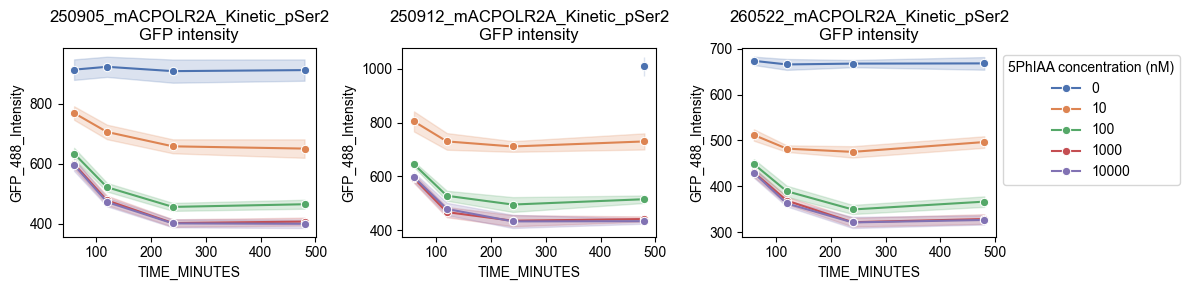

In [34]:
f, a = plt.subplots(ncols = 3, figsize = (12,3))

h = sns.lineplot(
    IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
    x = 'TIME_MINUTES',
    y = 'GFP_488_Intensity',
    hue = 'DRUG_CONCENTRATION',
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[0],
    legend = False
)

h = sns.lineplot(
    IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
    x = 'TIME_MINUTES',
    y = 'GFP_488_Intensity',
    hue = 'DRUG_CONCENTRATION',
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[1],
    legend = False
)

h = sns.lineplot(
    IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
    x = 'TIME_MINUTES',
    y = 'GFP_488_Intensity',
    hue = 'DRUG_CONCENTRATION',
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[2]
)

a[2].legend(title='5PhIAA concentration (nM)', bbox_to_anchor = (1,1))

a[0].set_title('250905_mACPOLR2A_Kinetic_pSer2\nGFP intensity')
a[1].set_title('250912_mACPOLR2A_Kinetic_pSer2\nGFP intensity')
a[2].set_title('260522_mACPOLR2A_Kinetic_pSer2\nGFP intensity')

plt.tight_layout()

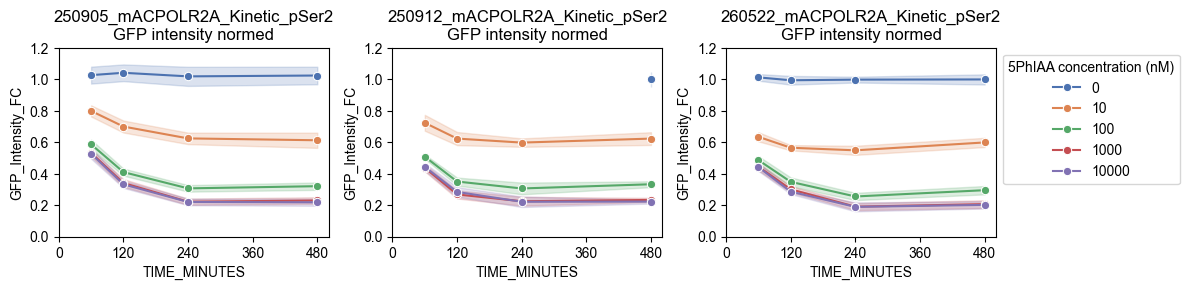

In [35]:
f, a = plt.subplots(ncols = 3, figsize = (12,3))

h = sns.lineplot(
    IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
    x = 'TIME_MINUTES',
    y = 'GFP_Intensity_FC',
    hue = 'DRUG_CONCENTRATION',
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[0],
    legend = False
)

h = sns.lineplot(
    IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
    x = 'TIME_MINUTES',
    y = 'GFP_Intensity_FC',
    hue = 'DRUG_CONCENTRATION',
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[1],
    legend = False
)

h = sns.lineplot(
    IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
    x = 'TIME_MINUTES',
    y = 'GFP_Intensity_FC',
    hue = 'DRUG_CONCENTRATION',
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[2]
)

a[2].legend(title='5PhIAA concentration (nM)', bbox_to_anchor = (1,1))

for ax in a:
    ax.set_xticks(np.linspace(0,480,5))
    ax.set_ylim(0,1.2)
    ax.set_box_aspect(0.7)

a[0].set_title('250905_mACPOLR2A_Kinetic_pSer2\nGFP intensity normed')
a[1].set_title('250912_mACPOLR2A_Kinetic_pSer2\nGFP intensity normed')
a[2].set_title('260522_mACPOLR2A_Kinetic_pSer2\nGFP intensity normed')

plt.tight_layout()

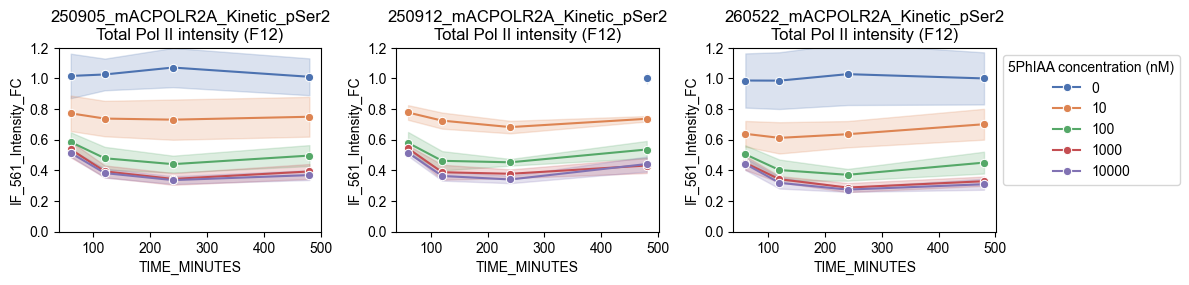

In [36]:
f, a = plt.subplots(ncols = 3, figsize = (12,3))

h = sns.lineplot(
    Total_IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
    x = 'TIME_MINUTES',
    y = 'IF_561_Intensity_FC',
    hue = 'DRUG_CONCENTRATION',
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[0],
    legend = False
)

h = sns.lineplot(
    Total_IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
    x = 'TIME_MINUTES',
    y = 'IF_561_Intensity_FC',
    hue = 'DRUG_CONCENTRATION',
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[1],
    legend = False
)

h = sns.lineplot(
    Total_IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
    x = 'TIME_MINUTES',
    y = 'IF_561_Intensity_FC',
    hue = 'DRUG_CONCENTRATION',
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[2]
)

a[2].legend(title='5PhIAA concentration (nM)', bbox_to_anchor = (1,1))

for ax in a:
    ax.set_ylim(0,1.2)
    ax.set_box_aspect(0.7)

a[0].set_title('250905_mACPOLR2A_Kinetic_pSer2\nTotal Pol II intensity (F12)')
a[1].set_title('250912_mACPOLR2A_Kinetic_pSer2\nTotal Pol II intensity (F12)')
a[2].set_title('260522_mACPOLR2A_Kinetic_pSer2\nTotal Pol II intensity (F12)')

plt.tight_layout()

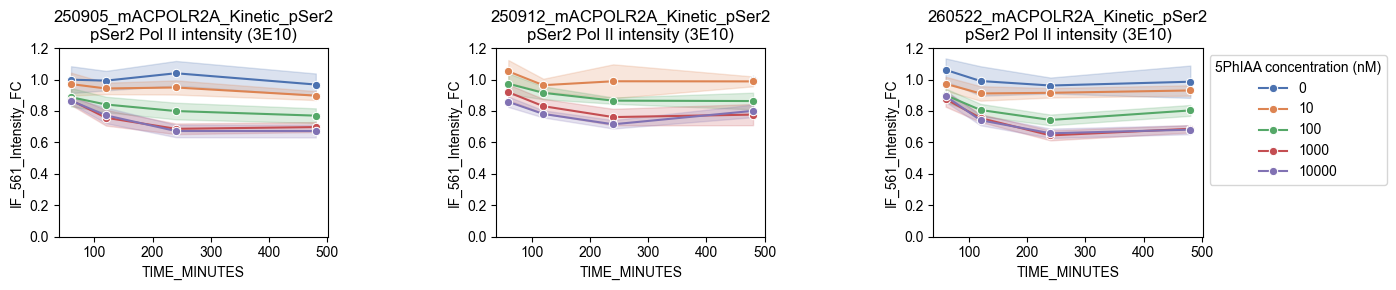

In [37]:
f, a = plt.subplots(ncols = 3, figsize = (15,3))

h = sns.lineplot(
    pSer2_IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
    x = 'TIME_MINUTES',
    y = 'IF_561_Intensity_FC',
    hue = 'DRUG_CONCENTRATION',
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[0],
    legend = False
)

h = sns.lineplot(
    pSer2_IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
    x = 'TIME_MINUTES',
    y = 'IF_561_Intensity_FC',
    hue = 'DRUG_CONCENTRATION',
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[1],
    legend = False
)

h = sns.lineplot(
    pSer2_IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
    x = 'TIME_MINUTES',
    y = 'IF_561_Intensity_FC',
    hue = 'DRUG_CONCENTRATION',
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[2]
)

a[2].legend(title='5PhIAA concentration (nM)', bbox_to_anchor = (1,1))

for ax in a:
    ax.set_ylim(0,1.2)
    ax.set_box_aspect(0.7)

a[0].set_title('250905_mACPOLR2A_Kinetic_pSer2\npSer2 Pol II intensity (3E10)')
a[1].set_title('250912_mACPOLR2A_Kinetic_pSer2\npSer2 Pol II intensity (3E10)')
a[2].set_title('260522_mACPOLR2A_Kinetic_pSer2\npSer2 Pol II intensity (3E10)')

plt.tight_layout()

## fold vehicle treatments into 0 timepoint

In [38]:
def time_in_aux(d,c,t):
    if d == "Vehicle":
        return 0
    elif c == 0:
        return 0
    elif d == "5PhIAA":
        return t

In [39]:
IntensitiesByWell['TIME_IN_AUXIN'] = IntensitiesByWell.apply(lambda x: time_in_aux(x['DRUG'],x['DRUG_CONCENTRATION'], x['TIME_MINUTES']), axis = 1)
IntensitiesByWell['TIME_IN_AUXIN_HRS'] = IntensitiesByWell['TIME_IN_AUXIN'] / 60

Total_IntensitiesByWell['TIME_IN_AUXIN'] = Total_IntensitiesByWell.apply(lambda x: time_in_aux(x['DRUG'],x['DRUG_CONCENTRATION'], x['TIME_MINUTES']), axis = 1)
Total_IntensitiesByWell['TIME_IN_AUXIN_HRS'] = Total_IntensitiesByWell['TIME_IN_AUXIN'] / 60

pSer2_IntensitiesByWell['TIME_IN_AUXIN'] = pSer2_IntensitiesByWell.apply(lambda x: time_in_aux(x['DRUG'],x['DRUG_CONCENTRATION'], x['TIME_MINUTES']), axis = 1)
pSer2_IntensitiesByWell['TIME_IN_AUXIN_HRS'] = pSer2_IntensitiesByWell['TIME_IN_AUXIN'] / 60

# publication plots

## normalised GFP, total Pol II, and pSer2 Pol II plots

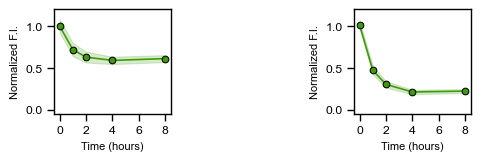

In [40]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (6,1.5), layout = 'constrained')

h = sns.lineplot(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & (DRUG_CONCENTRATION == 0 | DRUG_CONCENTRATION == 10)'),
                 x = 'TIME_IN_AUXIN_HRS',
                 y = 'GFP_Intensity_FC',
                 marker = 'o', markeredgecolor = 'black',
                 errorbar = 'sd',
                 color = 'xkcd:grass green',
                 ax = a[0],
                 legend = False)

h = sns.lineplot(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & (DRUG_CONCENTRATION == 0 | DRUG_CONCENTRATION == 1000)'),
                 x = 'TIME_IN_AUXIN_HRS',
                 y = 'GFP_Intensity_FC',
                 marker = 'o', markeredgecolor = 'black',
                 errorbar = 'sd',
                 color = 'xkcd:grass green',
                 ax = a[1],
                 legend = False)

for i in range(2):
    a[i].set_xlabel('Time (hours)', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.9)
    a[i].set_ylim(-0.05,1.2)
    a[i].set_yticks([0,0.5,1])
    a[i].set_xticks(np.linspace(0,8,5))

#plt.tight_layout()

plt.savefig('mACPOLR2A_10nM_1uM_mac_polii.svg')

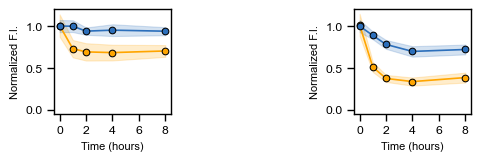

In [41]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (6,1.5), layout = 'constrained')

h = sns.lineplot(Total_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & (DRUG_CONCENTRATION == 0 | DRUG_CONCENTRATION == 10)'),
                 x = 'TIME_IN_AUXIN_HRS',
                 y = 'IF_561_Intensity_FC',
                 marker = 'o', markeredgecolor = 'black',
                 errorbar = 'sd',
                 color = 'orange',
                 ax = a[0],
                 legend = False)

h = sns.lineplot(pSer2_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & (DRUG_CONCENTRATION == 0 | DRUG_CONCENTRATION == 10)'),
                 x = 'TIME_IN_AUXIN_HRS',
                 y = 'IF_561_Intensity_FC',
                 marker = 'o', markeredgecolor = 'black',
                 errorbar = 'sd',
                 color = 'xkcd:medium blue',
                 ax = a[0],
                 legend = False)

h = sns.lineplot(Total_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & (DRUG_CONCENTRATION == 0 | DRUG_CONCENTRATION == 1000)'),
                 x = 'TIME_IN_AUXIN_HRS',
                 y = 'IF_561_Intensity_FC',
                 marker = 'o', markeredgecolor = 'black',
                 errorbar = 'sd',
                 color = 'orange',
                 ax = a[1],
                 legend = False)

h = sns.lineplot(pSer2_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & (DRUG_CONCENTRATION == 0 | DRUG_CONCENTRATION == 1000)'),
                 x = 'TIME_IN_AUXIN_HRS',
                 y = 'IF_561_Intensity_FC',
                 marker = 'o', markeredgecolor = 'black',
                 errorbar = 'sd',
                 color = 'xkcd:medium blue',
                 ax = a[1],
                 legend = False)

for i in range(2):
    a[i].set_xlabel('Time (hours)', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.9)
    a[i].set_ylim(-0.05,1.2)
    a[i].set_yticks([0,0.5,1])
    a[i].set_xticks(np.linspace(0,8,5))

#plt.tight_layout()

plt.savefig('mACPOLR2A_10nM_1uM_total_pser2_polii.svg')

In [42]:
IntensitiesByWell['DRUG_CONCENTRATION'].unique()

array([    0,    10,   100,  1000, 10000])

In [43]:
log_conc = dict(zip([0,10,100,1000,10000], [-12,-8,-7,-6,-5]))
IntensitiesByWell['DRUG_CONCENTRATION_LOG'] = IntensitiesByWell['DRUG_CONCENTRATION'].map(log_conc)

In [44]:
IntensitiesByWell['DRUG_CONCENTRATION_LOG'].unique()

array([-12,  -8,  -7,  -6,  -5])

## plot a concentration-response curve for 5-Ph-IAA and GFP loss

In [45]:
import scipy

In [46]:
def inhib_resp(x,b,ic):
    return b + (1 - b) /(1+10**(x - ic))

In [47]:
IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG_CONCENTRATION_LOG != 0 & TIME_IN_AUXIN_HRS == 4')[['DRUG_CONCENTRATION_LOG','GFP_Intensity_FC']].groupby(['DRUG_CONCENTRATION_LOG']).mean()

,GFP_Intensity_FC
DRUG_CONCENTRATION_LOG,
-8,0.589635
-7,0.288925
-6,0.212049
-5,0.209973


In [48]:
crc_x = [-8,-7,-6,-5]
crc_y = IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG_CONCENTRATION_LOG != 0 & TIME_IN_AUXIN_HRS == 4')[['DRUG_CONCENTRATION_LOG','GFP_Intensity_FC']].groupby(['DRUG_CONCENTRATION_LOG']).mean().GFP_Intensity_FC.tolist()

In [49]:
params, _ = scipy.optimize.curve_fit(inhib_resp, crc_x, crc_y, p0=[0.2, -7])

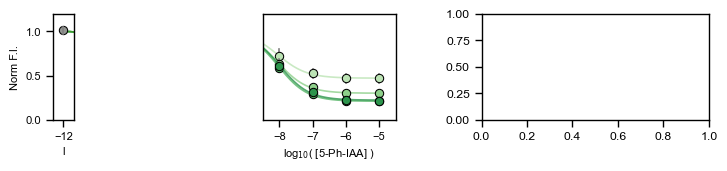

In [50]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 3, figsize = (8,1.8))

colour_list = [sns.color_palette('Greens')[c] for c in [1,2,3,4]]

for i,t in enumerate([1,2,4,8]):
    crc_x = [-8,-7,-6,-5]
    crc_y = IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG_CONCENTRATION_LOG != 0 & TIME_IN_AUXIN_HRS == @t')[['DRUG_CONCENTRATION_LOG','GFP_Intensity_FC']].groupby(['DRUG_CONCENTRATION_LOG']).mean().GFP_Intensity_FC.tolist()
    params, _ = scipy.optimize.curve_fit(inhib_resp, crc_x, crc_y, p0=[0.2, -7])
    plot_x = np.linspace(-12,-5,1000)
    plot_y = [inhib_resp(i, params[0], params[1]) for i in plot_x]
    sns.lineplot(x = plot_x,
             y = plot_y,
             ax = a[0],
             color = colour_list[i],
             alpha = 0.8)
    sns.lineplot(x = plot_x,
             y = plot_y,
             ax = a[1],
             color = colour_list[i],
             alpha = 0.8)

    sns.lineplot(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG_CONCENTRATION_LOG != 0 & TIME_IN_AUXIN_HRS == @t'),
            x = 'DRUG_CONCENTRATION_LOG',
            y = 'GFP_Intensity_FC',
         marker = '',
         errorbar = 'sd',
         err_style='bars',  err_kws = {'ecolor' : 'grey'},
         linestyle ='',
         ax = a[1])

    
    sns.lineplot(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG_CONCENTRATION_LOG != 0 & TIME_IN_AUXIN_HRS == @t'),
                x = 'DRUG_CONCENTRATION_LOG',
                y = 'GFP_Intensity_FC',
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             color = colour_list[i],
             errorbar = None,
             
             linestyle ='',
             ax = a[1])


sns.lineplot(x = plot_x,
             y = plot_y,
             ax = a[0],
             color = 'xkcd:grass green',
             alpha = 0.5)

sns.lineplot(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG_CONCENTRATION == 0'),
                x = 'DRUG_CONCENTRATION_LOG',
                y = 'GFP_Intensity_FC',
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             color = 'xkcd:grey',
             errorbar = 'sd',
             err_style='bars', err_kws = {'ecolor' : 'grey'},
             linestyle ='',
             ax = a[0])


a[0].set_ylim(0,1.2)
a[1].set_ylim(0,1.2)

a[0].set_box_aspect(5)
a[1].set_box_aspect(0.8)
a[0].set_xlim(-14,-10)
a[1].set_xlim(-8.5,-4.5)

a[0].set_xticks([-12])
a[1].set_xticks([-8,-7,-6,-5])

a[1].set_ylabel('')
a[1].set_yticks([])

a[0].set_ylabel('Norm F.I.',fontsize = 8)
a[0].set_xlabel('l', fontsize = 8)
a[1].set_xlabel('log$ _{10} $( [5-Ph-IAA] )', fontsize = 8)

a[0].tick_params(axis = 'both', labelsize = 8)
a[1].tick_params(axis = 'both', labelsize = 8)

f.tight_layout()

plt.savefig('mACPOLR2A_GFP_crc.svg')

## total pol II versus active pol II xy scatterplot

In [51]:
# pull means and standard deviation values for both total Pol II IF and pSer2 IF for all vehicle treated wells

Total_Vehicle_Mean = Total_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG_CONCENTRATION == 0')['IF_561_Intensity_FC'].mean()
Total_Vehicle_SD = Total_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG_CONCENTRATION == 0')['IF_561_Intensity_FC'].std()
pSer2_Vehicle_Mean = pSer2_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG_CONCENTRATION == 0')['IF_561_Intensity_FC'].mean()
pSer2_Vehicle_SD = pSer2_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG_CONCENTRATION == 0')['IF_561_Intensity_FC'].std()

In [52]:
# pull means and standard deviation values for both total Pol II IF and pSer2 IF, grouped by each concentration and timepoint

TotalGroupedMean = Total_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"')[['DRUG_CONCENTRATION','TIME_MINUTES','IF_561_Intensity_FC']].groupby(['DRUG_CONCENTRATION','TIME_MINUTES']).mean().reset_index()
TotalGroupedSD = Total_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"')[['DRUG_CONCENTRATION','TIME_MINUTES','IF_561_Intensity_FC']].groupby(['DRUG_CONCENTRATION','TIME_MINUTES']).std().reset_index()

pSer2GroupedMean = pSer2_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"')[['DRUG_CONCENTRATION','TIME_MINUTES','IF_561_Intensity_FC']].groupby(['DRUG_CONCENTRATION','TIME_MINUTES']).mean().reset_index()
pSer2GroupedSD = pSer2_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"')[['DRUG_CONCENTRATION','TIME_MINUTES','IF_561_Intensity_FC']].groupby(['DRUG_CONCENTRATION','TIME_MINUTES']).std().reset_index()

In [53]:
TotalGroupedMean['TotalPolII'] = TotalGroupedMean['IF_561_Intensity_FC']
pSer2GroupedMean['pSer2PolII'] = pSer2GroupedMean['IF_561_Intensity_FC']

In [54]:
TotalGroupedSD['TotalPolII_SD'] = TotalGroupedSD['IF_561_Intensity_FC']
pSer2GroupedSD['pSer2PolII_SD'] = pSer2GroupedSD['IF_561_Intensity_FC']

In [55]:
XYPLOT = TotalGroupedMean[['DRUG_CONCENTRATION','TIME_MINUTES','TotalPolII']].merge(pSer2GroupedMean[['DRUG_CONCENTRATION','TIME_MINUTES','pSer2PolII']])

In [56]:
XYPLOT = XYPLOT.merge(TotalGroupedSD[['DRUG_CONCENTRATION','TIME_MINUTES','TotalPolII_SD']])
XYPLOT = XYPLOT.merge(pSer2GroupedSD[['DRUG_CONCENTRATION','TIME_MINUTES','pSer2PolII_SD']])

In [57]:
XYPLOT 

,DRUG_CONCENTRATION,TIME_MINUTES,TotalPolII,pSer2PolII,TotalPolII_SD,pSer2PolII_SD
0,0,60,1.001303,1.030374,0.150754,0.080642
1,0,120,1.005762,0.991699,0.140585,0.073670
2,0,240,1.049552,1.000904,0.158129,0.073883
3,0,480,1.003607,0.984682,0.110345,0.068211
4,10,60,0.729362,0.998661,0.103577,0.070390
5,10,120,0.691425,0.939335,0.103632,0.043765
6,10,240,0.682951,0.951212,0.093852,0.070353
7,10,480,0.729028,0.938637,0.089003,0.048117
8,100,60,0.556265,0.920441,0.069756,0.064410
9,100,120,0.447517,0.854105,0.071196,0.061639


/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82654/3118819400.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  XYPLOT_5PH['LOG_DRUG_CONC'] = np.log10(XYPLOT_5PH['DRUG_CONCENTRATION']*1e-9)


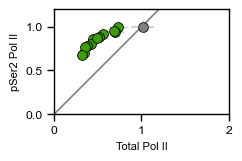

In [58]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (5,1.5), layout = 'constrained')

XYPLOT_5PH = XYPLOT.query('DRUG_CONCENTRATION > 0 & TIME_MINUTES <= 240')
XYPLOT_5PH['LOG_DRUG_CONC'] = np.log10(XYPLOT_5PH['DRUG_CONCENTRATION']*1e-9)

# plot error bars for vehicle treated point

plt.errorbar(x = [Total_Vehicle_Mean], 
             xerr = [Total_Vehicle_SD],
             y = [pSer2_Vehicle_Mean], 
             yerr = [pSer2_Vehicle_SD],
             color = 'grey',
             alpha = 0.4)

# plot error bars for 5-ph-iaa treated points

plt.errorbar(x = XYPLOT_5PH.TotalPolII,
             xerr = XYPLOT_5PH.TotalPolII_SD,
             y = XYPLOT_5PH.pSer2PolII,
             yerr = XYPLOT_5PH.pSer2PolII_SD,
             linestyle = "None", linewidth = 1,
             color = 'grey', 
             alpha = 0.4, zorder = 1)

# plot vehicle treated point in grey

sns.scatterplot(x = [Total_Vehicle_Mean], y = [pSer2_Vehicle_Mean], color = 'grey', s = 50, edgecolor = 'black')

# plot total and pSer2 at each time and concentration

h = sns.scatterplot(XYPLOT_5PH.query('LOG_DRUG_CONC in [-8,-7,-6,-5]'),
                x = 'TotalPolII',
                y = 'pSer2PolII',

                color = 'xkcd:grass green',
                marker = 'o', s = 50, edgecolor = 'black')

a.set_box_aspect(0.6)
a.set_ylim(0,1.2)
a.set_xlim(0,2)
a.set_xticks([0,1.0,2.0])
a.set_yticks([0,0.5,1,])

a.axline(xy1 = (0,0), slope = 1, color = 'grey', zorder = 0)

a.set_xlabel('Total Pol II', fontsize = 8)

a.set_ylabel('pSer2 Pol II', fontsize = 8)

plt.savefig('total_polii_vs_pser2_polii_mACPOLR2A_kinetic_pser2.svg')

In [59]:
pSer2_IntensitiesByWell

,WELL,IF_561_Intensity,GFP_488_Intensity,DAPI_Intensity,NucleusArea,CELL,DRUG,DRUG_CONCENTRATION,TIME_MINUTES,PRIMARY,...,EXPERIMENT,ROW,COLUMN,GFP_Intensity_BGS,GFP_Intensity_FC,IF_561_Intensity_BGS,IF_561_Intensity_FC,IF_647_Intensity,TIME_IN_AUXIN,TIME_IN_AUXIN_HRS
5,C13,2479.962438,258.033201,453.168211,1509.502082,HCT116 OsTIRF74G,Vehicle,0,480,pSer2 Pol II (3E10),...,250905_mACPOLR2A_Kinetic_pSer2,C,13,-2.209158,-0.003466,2299.237173,1.663108,NaN,0,0.0
6,C14,2216.164514,257.985919,399.452800,1606.558899,HCT116 OsTIRF74G,Vehicle,0,480,pSer2 Pol II (3E10),...,250905_mACPOLR2A_Kinetic_pSer2,C,14,-2.256439,-0.003540,2035.439249,1.472295,NaN,0,0.0
7,C15,2345.742875,254.885339,431.099886,1612.445588,HCT116 OsTIRF74G,Vehicle,0,480,pSer2 Pol II (3E10),...,250905_mACPOLR2A_Kinetic_pSer2,C,15,-5.357019,-0.008405,2165.017610,1.566023,NaN,0,0.0
8,C16,2163.775434,254.414720,395.110229,1622.399506,HCT116 OsTIRF74G,Vehicle,0,480,pSer2 Pol II (3E10),...,250905_mACPOLR2A_Kinetic_pSer2,C,16,-5.827639,-0.009144,1983.050168,1.434401,NaN,0,0.0
19,D13,2067.819039,255.374220,374.281142,1621.884772,HCT116 OsTIRF74G,Vehicle,0,480,pSer2 Pol II (3E10),...,250905_mACPOLR2A_Kinetic_pSer2,D,13,-4.868138,-0.007638,1887.093773,1.364992,NaN,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223,N06,1032.764029,242.031790,355.937561,1738.760918,HCT116 OsTIRF74G,Vehicle,0,480,pSer2 Pol II (3E10),...,260522_mACPOLR2A_Kinetic_pSer2,N,06,1.545973,0.003610,883.603794,1.071897,2108.389999,0,0.0
224,N07,964.620903,243.239431,343.479556,1736.905464,HCT116 OsTIRF74G,Vehicle,0,480,pSer2 Pol II (3E10),...,260522_mACPOLR2A_Kinetic_pSer2,N,07,2.753614,0.006429,815.460668,0.989233,2155.995014,0,0.0
225,N08,1043.194328,240.113471,366.522624,1790.563009,HCT116 OsTIRF74G,Vehicle,0,480,pSer2 Pol II (3E10),...,260522_mACPOLR2A_Kinetic_pSer2,N,08,-0.372346,-0.000869,894.034093,1.084550,2098.768702,0,0.0
226,N09,1052.160710,242.273605,375.670352,1832.508868,HCT116 OsTIRF74G,Vehicle,0,480,pSer2 Pol II (3E10),...,260522_mACPOLR2A_Kinetic_pSer2,N,09,1.787789,0.004174,903.000475,1.095427,2186.166806,0,0.0


In [60]:
CELL_NAME = "HCT116 OsTIRF74G mAC-POLR2A Clone 5"
TIME_COL = "TIME_MINUTES"
TIME_VALUE = 240
INTENSITY_COL = "IF_561_Intensity_FC"

pser2 = pSer2_IntensitiesByWell.query("CELL == @CELL_NAME").copy()

# vehicle normalization
pser2_vehicle_mean = pser2.loc[pser2["DRUG"] == "Vehicle", INTENSITY_COL].mean()
pser2["Norm_Intensity"] = pser2[INTENSITY_COL] / pser2_vehicle_mean

# 4 h treated wells only
treated = pser2.loc[
    (pser2[TIME_COL] == TIME_VALUE) &
    (pser2["DRUG_CONCENTRATION"] > 0)
].copy()

treated_summary = (
    treated.groupby("DRUG_CONCENTRATION")["Norm_Intensity"]
    .agg(Mean="mean", SD="std", N="size")
    .reset_index()
)

vehicle = pd.DataFrame({
    "DRUG_CONCENTRATION": [0],
    "Mean": [pser2.loc[pser2["DRUG"] == "Vehicle", "Norm_Intensity"].mean()],
    "SD": [pser2.loc[pser2["DRUG"] == "Vehicle", "Norm_Intensity"].std()],
    "N": [pser2.loc[pser2["DRUG"] == "Vehicle"].shape[0]]
})

pser2_export = pd.concat([vehicle, treated_summary], ignore_index=True)

pser2_export.to_csv("mACPOLR2A_pSer2_4h_normalized.csv", index=False)
pser2_export

,DRUG_CONCENTRATION,Mean,SD,N
0,0,1.000000,0.072439,36
1,10,0.951212,0.070353,12
2,100,0.802465,0.062866,12
3,1000,0.697060,0.062270,12
4,10000,0.681542,0.038791,12


In [61]:
# export all 3 reps for model fitting

In [62]:
CELL_NAME = "HCT116 OsTIRF74G mAC-POLR2A Clone 5"

pser2 = pSer2_IntensitiesByWell.query("CELL == @CELL_NAME").copy()
total = Total_IntensitiesByWell.query("CELL == @CELL_NAME").copy()

group_keys = ['EXPERIMENT', 'TIME_IN_AUXIN_HRS', 'DRUG_CONCENTRATION']

pser2_means = pser2.groupby(group_keys)['IF_561_Intensity_FC'].mean().reset_index()
total_means = total.groupby(group_keys)['IF_561_Intensity_FC'].mean().reset_index()

export = pser2_means.merge(total_means, on=group_keys, suffixes=('_pSer2', '_Total'))

export['EXPERIMENT'] = export['EXPERIMENT'].str[:6].astype(int)

export = export.rename(columns={
    'DRUG_CONCENTRATION':        'AUXIN_CONCENTRATION_nM',
    'IF_561_Intensity_FC_pSer2': 'pSer2_PolII_3E10_Normed',
    'IF_561_Intensity_FC_Total': 'Total_PolII_F12_Normed',
})

export.to_csv('mACPOLR2A_pSer2PolII_8hours_Values_ByExperiment_3reps.csv', index=False)
